In [1]:
# matplotlib.pyplot: figure and axes management
# pandas: DataFrame loading, filtering, and type casting
# numpy: array operations and z-score computation support
# scipy.spatial.ConvexHull: computes the minimal convex polygon enclosing a set of 2D points,
#   used here to define a player's spatial "action radius" on the pitch
# matplotlib as mpl: used for global rcParams configuration
# mplsoccer.Pitch: horizontal pitch renderer
# scipy.stats: provides the zscore() function for outlier detection
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib as mpl
from mplsoccer import Pitch
from scipy import stats

# Load the action dataset from a custom CSV.
# Each row represents a single on-ball action by a player with spatial coordinates.
# fillna(0) replaces all NaN values with 0 to prevent downstream errors in numerical operations
# and to allow ConvexHull to receive a fully populated point array.
df = pd.read_csv("convextutorial7.csv")
df = df.fillna(0)

# Rescale raw coordinates to the StatsBomb 120x80 pitch system,
# applying the same linear mapping used in notebook 6.
df['x'] = df['x'] * 1.2
df['y'] = df['y'] * 0.8

# Filter to a single team (teamId=65) to isolate the analysis.
# reset_index() resets the row index after filtering so subsequent .iloc[] and .at[] calls
# reference the correct positions within the filtered DataFrame.
df = df[df['teamId'] == 65].reset_index()

# Cast playerId to int to ensure consistent type for filtering and sorting.
# Player IDs loaded from CSV may be parsed as floats if any values were missing before fillna.
df['playerId'] = df['playerId'].astype(int)

# Extract the unique player IDs present in the dataset.
# The first 11 entries correspond to the starting lineup (players are ordered by appearance time).
# sort() arranges them in ascending ID order for consistent presentation.
players = df['playerId'].unique()
starters = players[0:11]
starters.sort()
starters

array([ 0,  1,  4,  5,  7,  9, 11, 18, 21, 23, 28])

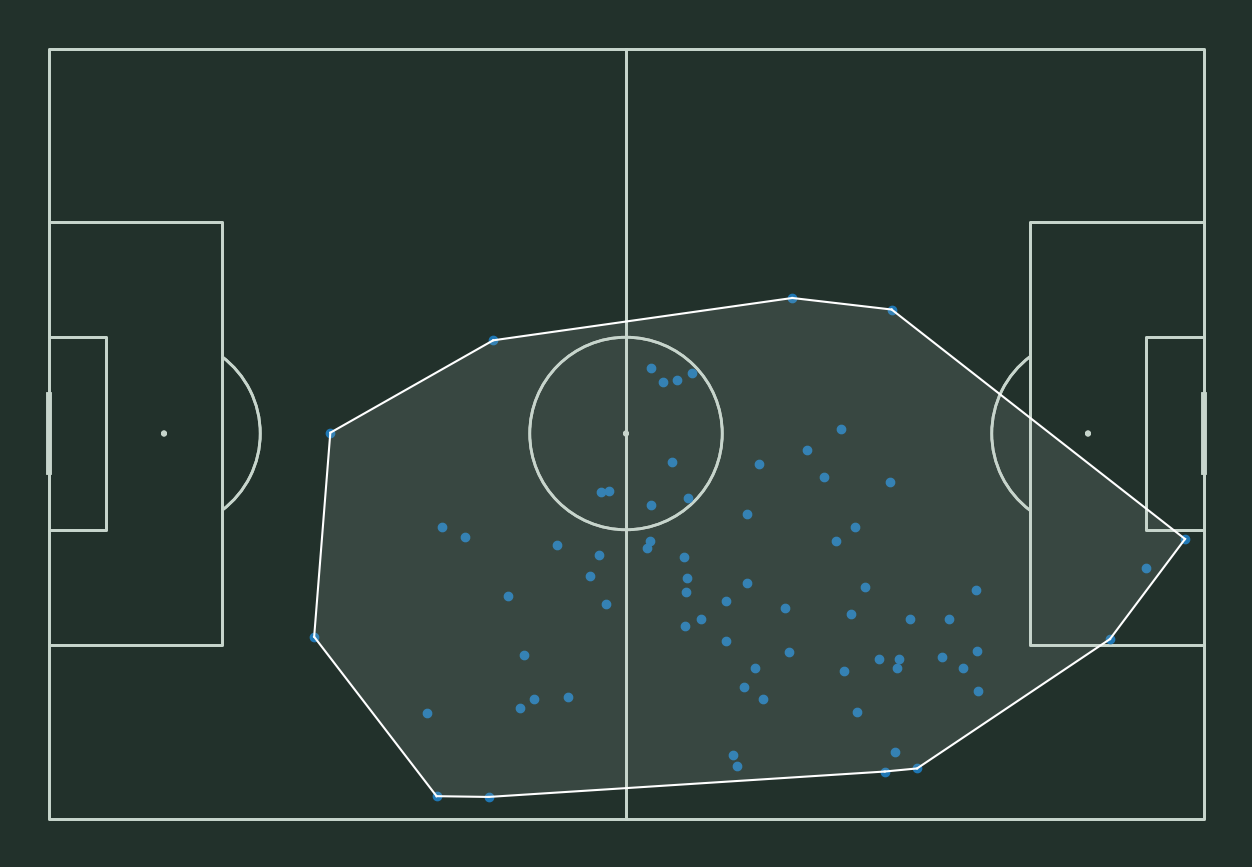

In [2]:
# Draw a dark-themed StatsBomb horizontal pitch.
# pitch_type='statsbomb' aligns the axes to the 120x80 coordinate system.
# invert_yaxis() is called after drawing to match the top-to-bottom pitch orientation.
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('#22312b')
pitch.draw(ax=ax)
plt.gca().invert_yaxis()

# Filter to a single player (playerId=21) and a specific action type (type/value=1).
# type/value=1 typically represents a specific action category in the source data schema
# (e.g., touches, carries, or a team-specific event classification).
df1 = df[df['playerId'] == 21]
df1 = df1[df1['type/value'] == 1]

# Remove spatial outliers using z-score filtering.
# stats.zscore() computes the z-score for each observation in the x and y columns
# (number of standard deviations from the column mean).
# np.abs(...) < 3 retains only rows where both x and y are within 3 standard deviations.
# This removes actions recorded at erroneous or extreme positions — common in CSV-derived
# data where tracking errors produce coordinates far outside the pitch boundary.
# Outlier removal is critical before ConvexHull: a single extreme point would dramatically
# distort the hull and misrepresent the player's true action zone.
df1 = df1[(np.abs(stats.zscore(df1[['x', 'y']])) < 3).all(axis=1)]

# Extract the (x, y) coordinate pairs as a numpy array for ConvexHull input.
points = df1[['x', 'y']].values

# ConvexHull() computes the minimal convex polygon that encloses all filtered action points.
# This polygon represents the player's maximum spatial coverage — the outer boundary
# of all positions where they were involved in this action type during the match.
# hull.simplices contains index pairs defining each edge of the convex hull triangulation.
# hull.vertices contains the indices of the vertices on the outer boundary polygon.
hull = ConvexHull(df1[['x', 'y']])

# Scatter plot all filtered action coordinates as individual points.
plt.scatter(df1.x, df1.y)

# Draw the convex hull boundary by iterating over hull.simplices.
# Each simplex is a pair of point indices defining one edge of the hull.
# points[i, 0] and points[i, 1] index the x and y coordinates of the two edge endpoints.
# plt.fill() fills the convex hull polygon with a near-transparent white (alpha=0.01),
# creating a subtle shading that distinguishes the player's action zone from the rest of the pitch.
for i in hull.simplices:
    plt.plot(points[i, 0], points[i, 1], 'white')
    plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], c='white', alpha=0.01)

## Summary: Player Action Radius via Convex Hull

### What This Notebook Does

This notebook computes and visualizes the spatial "action radius" of an individual player using a convex hull — the smallest convex polygon that encloses all of the player's recorded action coordinates. The hull provides an interpretable, non-parametric representation of a player's coverage zone for a specific action type during a match.

### Key Concepts

- **`scipy.spatial.ConvexHull`**: Given a set of 2D points, `ConvexHull()` computes the minimal convex polygon containing all of them using the Quickhull algorithm. The result exposes `hull.vertices` (indices of the outer boundary points) and `hull.simplices` (index pairs for each triangulated edge). For pitch analysis, the hull area is a direct measure of how much of the pitch a player covered in a given action type.
- **Z-score outlier removal** (`scipy.stats.zscore`): `stats.zscore(df[['x', 'y']])` computes the number of standard deviations each observation is from the column mean. The `(np.abs(...) < 3).all(axis=1)` mask retains rows where both coordinates are within 3σ of the mean. This step is mandatory before ConvexHull: a single GPS or tracking error far from the pitch would expand the hull to cover the entire pitch, destroying the analysis.
- **`type/value` action filtering**: The analysis is restricted to `type/value == 1`, which selects a specific action category from the source data schema. Filtering by action type lets you compute separate hulls for different roles (e.g., defensive actions vs attacking actions) for the same player.
- **`fillna(0)` caution**: Replacing NaN coordinates with `(0, 0)` fills missing location data with the bottom-left corner of the pitch. This is acceptable here because the z-score filter will remove the resulting cluster at `(0, 0)` as an outlier, but it introduces a small risk if a player genuinely has many actions near that coordinate.
- **Hull area as a tactical metric**: The `hull.volume` attribute (in 2D, this is the polygon area in pitch units squared) can be used directly as a scalar measure of a player's spatial coverage. Players with large hull areas cover more ground; players with small hull areas operate in concentrated zones.

### Data Available

| Object | Description |
|---|---|
| `df1` | Z-score filtered action coordinates for player 21, action type 1, in the StatsBomb 120x80 system |
| `points` | Numpy array of `(x, y)` coordinates passed to ConvexHull |
| `hull` | `ConvexHull` object exposing `hull.vertices`, `hull.simplices`, and `hull.volume` (area) |
| `starters` | Sorted array of the 11 starting player IDs for team 65 |

### Ideas to Extract More Value

- **All-starters hull overlay**: Loop over `starters` and compute a ConvexHull for each player, rendering all 11 hulls on the same pitch with distinct colors. The resulting visualization immediately reveals the team's spatial organization and role separation.
- **Hull area ranking**: Compute `hull.volume` (polygon area) for each player and rank them. High-area players are wide-ranging; low-area players are positionally disciplined. This distinguishes defensive lineholders from press-heavy midfielders.
- **Action type comparison per player**: Compute separate hulls for different `type/value` categories for the same player and overlay them. The difference between the defensive-action hull and the attacking-action hull reveals asymmetric positional behavior (e.g., a full-back who defends deep but attacks wide).
- **Alpha shape (concave hull)**: The convex hull includes empty space within the boundary that the player never actually occupied. Replacing it with an alpha shape (available via the `alphashape` library) produces a tighter, non-convex boundary that more accurately represents the player's true coverage zone.
- **Temporal hull evolution**: Split the match into 15-minute windows and compute a hull for each window. Animating or stacking these hulls shows how a player's coverage zone shifts throughout the match — useful for detecting fatigue, tactical adjustments, or pressing triggers.